# **ECE2112: Programming Assessment 4**

*Submitted by: Jazmine Mikaela L. Rafols | 2ECE-D*   
*Submitted on: September 9, 2026*

## **A. Visayas Communication Dataframe**

---

In [79]:
import pandas as pd

In [80]:
ECE_BoardExam_2 = pd.read_excel('board2.xlsx')
ECE_BoardExam_2

,Name,Gender,Track,Hometown,Math,Electronics,GEAS,Communication
0,S1,Male,Instrumentation,Luzon,58,89,75,78
1,S2,Female,Communication,Mindanao,52,75,90,52
2,S3,Female,Instrumentation,Mindanao,83,74,77,57
3,S4,Male,Instrumentation,Visayas,65,58,91,68
4,S5,Male,Communication,Luzon,59,86,43,88
5,S6,Female,Microelectronics,Visayas,88,45,86,83
6,S7,Female,Instrumentation,Luzon,66,60,60,48
7,S8,Male,Instrumentation,Luzon,49,81,64,53
8,S9,Male,Instrumentation,Luzon,50,36,63,42
9,S10,Male,Microelectronics,Mindanao,80,84,61,44


In [81]:
ECE_BoardExam_2['Average'] = ECE_BoardExam_2[['Math','Electronics','GEAS','Communication']].mean(axis=1)
ECE_BoardExam_2 # Display DataFrame WITH the `Average` column

,Name,Gender,Track,Hometown,Math,Electronics,GEAS,Communication,Average
0,S1,Male,Instrumentation,Luzon,58,89,75,78,75.00
1,S2,Female,Communication,Mindanao,52,75,90,52,67.25
2,S3,Female,Instrumentation,Mindanao,83,74,77,57,72.75
3,S4,Male,Instrumentation,Visayas,65,58,91,68,70.50
4,S5,Male,Communication,Luzon,59,86,43,88,69.00
5,S6,Female,Microelectronics,Visayas,88,45,86,83,75.50
6,S7,Female,Instrumentation,Luzon,66,60,60,48,58.50
7,S8,Male,Instrumentation,Luzon,49,81,64,53,61.75
8,S9,Male,Instrumentation,Luzon,50,36,63,42,47.75
9,S10,Male,Microelectronics,Mindanao,80,84,61,44,67.25


In [82]:
VisComm = ECE_BoardExam_2.loc[(ECE_BoardExam_2['Hometown']=='Visayas')&(ECE_BoardExam_2['Track']=='Communication'),
    ['Name','Gender','Math','Electronics','Average']]
VisComm # Condition: Visayas AND Communications

,Name,Gender,Math,Electronics,Average
10,S11,Female,48,56,54.75
11,S12,Male,89,67,76.00
17,S18,Male,81,40,63.50
21,S22,Female,64,39,62.50
27,S28,Male,85,53,67.75


In [83]:
print("Total number of rows in DataFrame, VisComm: ", VisComm.shape[0])

Total number of rows in DataFrame, VisComm:  5


## **B. Visayas Female Dataframe**

---

In [84]:
VisFemale = ECE_BoardExam_2.loc[(ECE_BoardExam_2['Hometown']=='Visayas')&(ECE_BoardExam_2['Gender']=='Female'),
    ['Name','Track','GEAS','Electronics','Average']]
VisFemale # Condition: Visayas AND Female

,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,75.50
10,S11,Communication,48,56,54.75
20,S21,Microelectronics,68,51,68.50
21,S22,Communication,89,39,62.50
23,S24,Microelectronics,60,45,57.75
25,S26,Instrumentation,83,47,65.75


In [85]:
VisFemale.loc[(VisFemale['Average']>=60)] # Condition: Female students whose average is at least 60

,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,75.50
20,S21,Microelectronics,68,51,68.50
21,S22,Communication,89,39,62.50
25,S26,Instrumentation,83,47,65.75


## **C. Category-Average Visualization**

---

In [86]:
import matplotlib.pyplot as plt

In [87]:
Average_Track = ECE_BoardExam_2.pivot_table(index='Track', values = 'Average').reset_index()
Average_Track

,Track,Average
0,Communication,67.975
1,Instrumentation,65.225
2,Microelectronics,67.500


In [88]:
Average_Gender = ECE_BoardExam_2.pivot_table(index='Gender', values = 'Average').reset_index()
Average_Gender

,Gender,Average
0,Female,66.616667
1,Male,67.183333


In [89]:
Average_Hometown = ECE_BoardExam_2.pivot_table(index='Hometown', values = 'Average').reset_index()
Average_Hometown

,Hometown,Average
0,Luzon,68.083333
1,Mindanao,66.678571
2,Visayas,65.750000


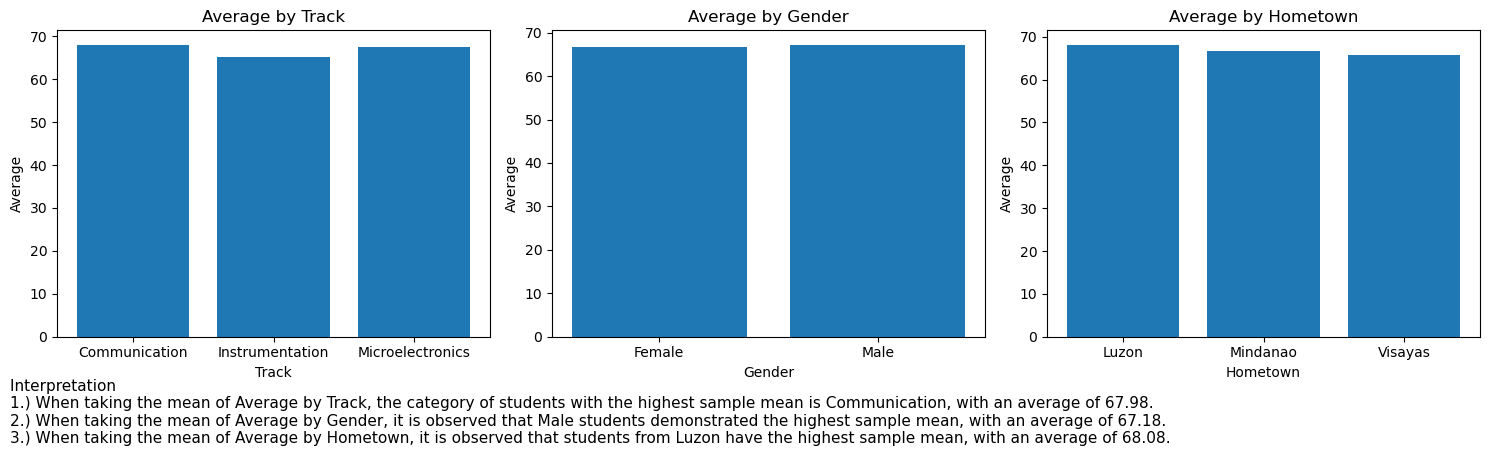

In [90]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.bar(Average_Track['Track'], Average_Track['Average'])
plt.title('Average by Track')
plt.xlabel('Track')
plt.ylabel('Average')

plt.subplot(1,3,2)
plt.bar(Average_Gender['Gender'], Average_Gender['Average'])
plt.xlabel('Gender')
plt.ylabel('Average')
plt.title('Average by Gender')

plt.subplot(1,3,3)
plt.bar(Average_Hometown['Hometown'], Average_Hometown['Average'])
plt.xlabel('Hometown')
plt.ylabel('Average')
plt.title('Average by Hometown')

plt.tight_layout()

interpretation = (
    "Interpretation \n"
    "1.) When taking the mean of Average by Track, the category of students with the highest sample mean is Communication, with an average of 67.98. \n"
    "2.) When taking the mean of Average by Gender, it is observed that Male students demonstrated the highest sample mean, with an average of 67.18. \n"
    "3.) When taking the mean of Average by Hometown, it is observed that students from Luzon have the highest sample mean, with an average of 68.08."
)

plt.figtext(0.01, -0.12, interpretation, fontsize=11, ha='left')
plt.show()